In [1]:
import torch
import matplotlib.pyplot as plt
import sys
import os
from pathlib import Path

PATH = str(os.getcwd()) 
__file__ = PATH + '/mcmc.ipynb'
root_dir = Path(__file__).resolve().parents[2]  # two levels up
sys.path.insert(0, str(root_dir))

import models
from models import baselines
from models.baselines.mcmc_bnn.mcmc import run_mcmc
from utils.data_utils import obtain_me_a_nice_sawtooth_dataset_please, obtain_me_a_nice_heaviside_dataset_please, obtain_me_a_nice_gp_dataset_please, ctxt_trgt_split
from utils.mcmc_utils import autocorrelation_array
from base_networks.base_architectures import Sin, SharpTanh

In [2]:
def build_meta_dataset(num_datasets=10_000, n_range=[40, 100], function_type='sawtooth', x_range=[-4.0, 4.0]):
    md = []
    assert function_type.lower() in ['sawtooth', 'gp', 'heaviside']

    if function_type.lower() == 'sawtooth':
        dataset_func = obtain_me_a_nice_sawtooth_dataset_please
        data_hypers = {'p': 0.75, 'm': 1.33, 'random_linear': True, 'x_range': [-2.0, 2.0]}
    elif function_type.lower() == 'gp':
        dataset_func = obtain_me_a_nice_gp_dataset_please
        data_hypers = {'l': 0.5, 'kernel': 'se', 'x_range': x_range}
    elif function_type.lower() == 'heaviside':
        dataset_func = obtain_me_a_nice_heaviside_dataset_please
        data_hypers = {'x_range': x_range, 'l': 1}

    for _ in range(num_datasets):
        X, y = dataset_func(n_range=n_range, **data_hypers)
        md.append((X, y))
    
    return md

In [3]:
device = torch.device('cpu')
torch.set_default_dtype(torch.float64)

hidden_dims = [16, 16]
prior = 'bnn'
model_name = 'lmc'
function_type = 'gp'


if prior is None:
    raise ValueError("User failed to specify the prior to use. Total fool.")
saved_models_path = Path(__file__).parent / "saved_models"
if prior != 'bnn':
    file = Path(saved_models_path / prior)
    if not file.is_file():
        raise ValueError("User failed to provide prior name corresponding to valid pretrained BDNP.")

if function_type == 'sawtooth':
    nonlinearity = 'relu'
elif function_type == 'heaviside':
    nonlinearity = 'tanh'
elif function_type == 'gp':
    nonlinearity = 'silu'

if nonlinearity.lower() == 'relu':
    nl = torch.nn.ReLU()
elif nonlinearity.lower() == 'sin':
    nl = Sin()
elif nonlinearity.lower() == 'tanh':
    nl = torch.nn.Tanh()
elif nonlinearity.lower() == 'sigmoid':
    nl = torch.nn.Sigmoid()
elif 'leaky' in nonlinearity.lower():
    nl = torch.nn.LeakyReLU()
elif nonlinearity.lower() == 'swish' or nonlinearity.lower() == 'silu':
    nl = torch.nn.SiLU()
elif nonlinearity.lower() == 'sharptanh':
    nl = SharpTanh()
else:
    raise NotImplementedError("Conversion to torch.nn module not yet implemented for provided nonlinearity string.")

lik = models.GaussianLikelihood(1, sigma_y=0.05)
model_kwargs = {'x_dim': 1,
                'y_dim': 1,
                'likelihood': lik,
                'hidden_dims': hidden_dims,
                'scale_prior': True,
                'nonlinearity': nl}

if model_name == 'hmc':
    model_class = baselines.HMC_BNN
elif model_name == 'lmc':
    model_class = baselines.LMC_BNN

model = model_class(**model_kwargs)

# adopt prior if using pre-trained one.
if prior.lower() != 'bnn':
    pretrained_bdnp = torch.load(PATH + f'/saved_models/{prior}', weights_only=False)
    layerwise_priors = []
    for layer in pretrained_bdnp.layers:
        m = layer.prior.mus.detach()
        if layer.prior_type == 1:
            S = layer.prior.Sigmas.detach()
        elif layer.prior_type == 0:
            S = layer.prior.sigmas.detach().diag_embed()
        else:
            raise ValueError(f"pre-trained BDNP has unsupported type of prior for adoption into {model_name} BNN.")
        layerwise_priors.append((m, S))
    model.adopt_prior(layerwise_priors)

In [4]:
X, y = build_meta_dataset(num_datasets=1, n_range=[10,11], function_type=function_type)[0]
xs = torch.linspace(-4.0, 4.0, 200).unsqueeze(-1)

if model_name.lower() == 'hmc':
    step_size = 1e-4
    steps = 10_000
else:
    step_size = 1e-5
    steps = 1_000_000


raw_samples, training_metrics = run_mcmc(model,
                            X,
                            y,
                            algorithm=model_name.lower(),
                            steps=steps,
                            step_size=step_size,
                            minibatch_size=None, # full-batch
                            metropolis_adjusted=True,
                            leapfrog_steps=100) # leapfrog_steps is silently ignored for LMC

100%|██████████| 1000000/1000000 [1:35:07<00:00, 175.22it/s, log-lik=-0.0207, log-prior=-112, log potential=112, average acceptance=0.479]   


In [8]:
if model_name.lower() == 'hmc':
    burn = 0
    thin = 100
else:
    burn = 25_000
    thin = 10_000

burned_in_samples = raw_samples[burn:] # do burn-in and thinning here
samples = burned_in_samples[::thin]

# training_metrics['autocorrelation'] = autocorrelation_array(raw_samples, max_lag=250)            

with torch.no_grad():
    pred_samps = model.batch_forward(xs, samples)
    num_samples = pred_samps.shape[0]

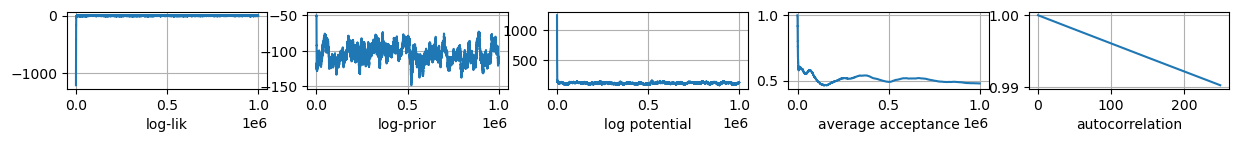

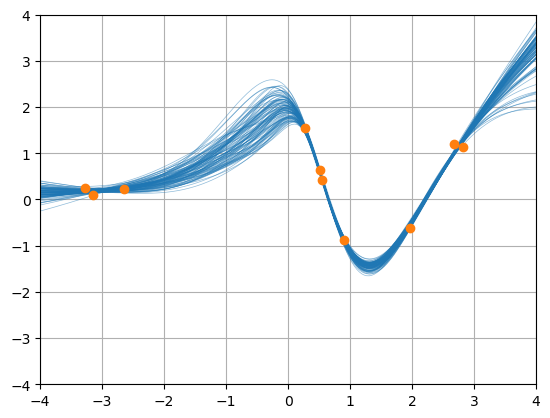

In [9]:
fig, axes = plt.subplots(1, len(training_metrics), figsize=(3*len(training_metrics), 1))
omitted_steps = 0
for i, (key, value) in enumerate(training_metrics.items()):
    axes[i].plot(value[omitted_steps:])
    axes[i].set_xlabel(key)
    axes[i].grid()
    if key == 'elbo':
        axes[i].set_ylim([-5000, 500])
    elif key == 'e_ll':
        axes[i].set_ylim([-4000, 1000])
    elif key == 'kl':
        axes[i].set_ylim([0, 2000])

plt.show()

plt.plot(xs.unsqueeze(0).repeat((pred_samps.shape[0], 1, 1)).squeeze(-1).T.cpu(), pred_samps.squeeze(-1).T.cpu(), linewidth=0.5, color='C0', alpha=0.5)
plt.scatter(X, y, color='C1', zorder=10000)
plt.grid()
lim = [-4.0, 4.0]
if function_type.lower() == 'sawtooth':
    lim = [-2.0, 2.0]
plt.xlim(lim)
plt.ylim(lim)
plt.show() 